In [21]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
air_quality = fetch_ucirepo(id=360) 
  
# data (as pandas dataframes) 
X = air_quality.data.features 
y = air_quality.data.targets 
  
# metadata 
print(air_quality.metadata) 
  
# variable information 
print(air_quality.variables) 


{'uci_id': 360, 'name': 'Air Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/360/air+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/360/data.csv', 'abstract': 'Contains the responses of a gas multisensor device deployed on the field in an Italian city. Hourly responses averages are recorded along with gas concentrations references from a certified analyzer. ', 'area': 'Computer Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 9358, 'num_features': 15, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C59K5F', 'creators': ['Saverio Vito'], 'intro_paper': {'ID': 420, 'type': 'NATIVE', 'title': 'On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario', 'authors': 

In [22]:
import pandas as pd

# X, y 합쳐서 데이터프레임 만들기
df = pd.concat([X, y], axis=1)

# 데이터 확인
print(df.shape)
df.head()

(9357, 15)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [23]:
# -200 값을 결측치로 변환
df.replace(-200, pd.NA, inplace=True)

# 결측치 확인
print(df.isnull().sum())

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


In [24]:
# NMHC(GT) 컬럼 제거 (결측치 너무 많음)
df.drop(columns=['NMHC(GT)', 'Date', 'Time'], inplace=True)

# 나머지 결측치는 평균으로 채우기
df.fillna(df.mean(), inplace=True)

# 확인
print(df.isnull().sum())
print(df.shape)

CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64
(9357, 12)


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# 목표변수: CO(GT) 예측
X = df.drop(columns=['CO(GT)'])
y = df['CO(GT)']

# 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 랜덤포레스트 학습
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 예측 및 평가
y_pred_rf = rf.predict(X_test)
print(f"Random Forest R2 Score: {r2_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest RMSE: {mean_squared_error(y_test, y_pred_rf)**.5:.4f}")

Random Forest R2 Score: 0.8733
Random Forest RMSE: 0.4850


In [26]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print(f"XGBoost R2 Score: {r2_score(y_test, y_pred_xgb):.4f}")
print(f"XGBoost RMSE: {mean_squared_error(y_test, y_pred_xgb)**.5:.4f}")

XGBoost R2 Score: 0.8616
XGBoost RMSE: 0.5069


In [27]:
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# XGBoost 하이퍼파라미터 튜닝
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1],
    'alpha': [0, 1],
    'lambda': [1, 10]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)
print("Best Parameters:", grid.best_params_)

Fitting 3 folds for each of 128 candidates, totalling 384 fits
Best Parameters: {'alpha': 1, 'colsample_bytree': 1, 'lambda': 10, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [28]:
# 최적 모델로 예측
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

# 평가
print(f"튜닝 후 XGBoost R2: {r2_score(y_test, y_pred_best):.4f}")
print(f"튜닝 후 XGBoost RMSE: {mean_squared_error(y_test, y_pred_best)**.5:.4f}")

튜닝 후 XGBoost R2: 0.8666
튜닝 후 XGBoost RMSE: 0.4977


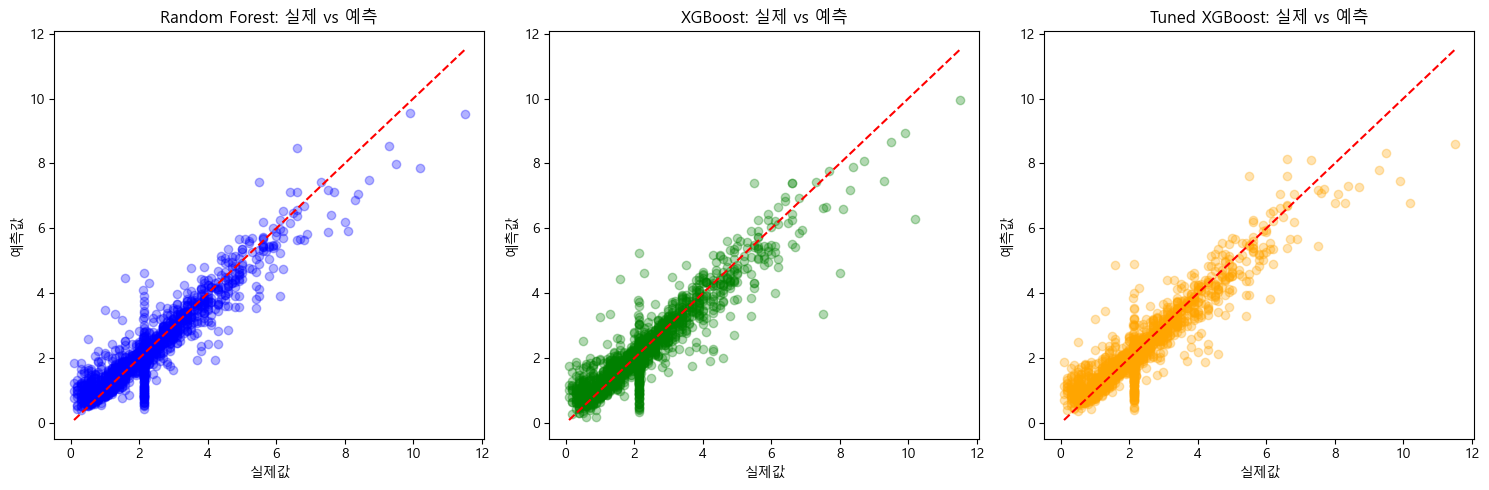

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, y_pred, title, color in zip(
    axes,
    [y_pred_rf, y_pred_xgb, y_pred_best],
    ['Random Forest: 실제 vs 예측', 'XGBoost: 실제 vs 예측', 'Tuned XGBoost: 실제 vs 예측'],
    ['blue', 'green', 'orange']
):
    ax.scatter(y_test, y_pred, alpha=0.3, color=color)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    ax.set_title(title)
    ax.set_xlabel('실제값')
    ax.set_ylabel('예측값')

plt.tight_layout()
plt.show()


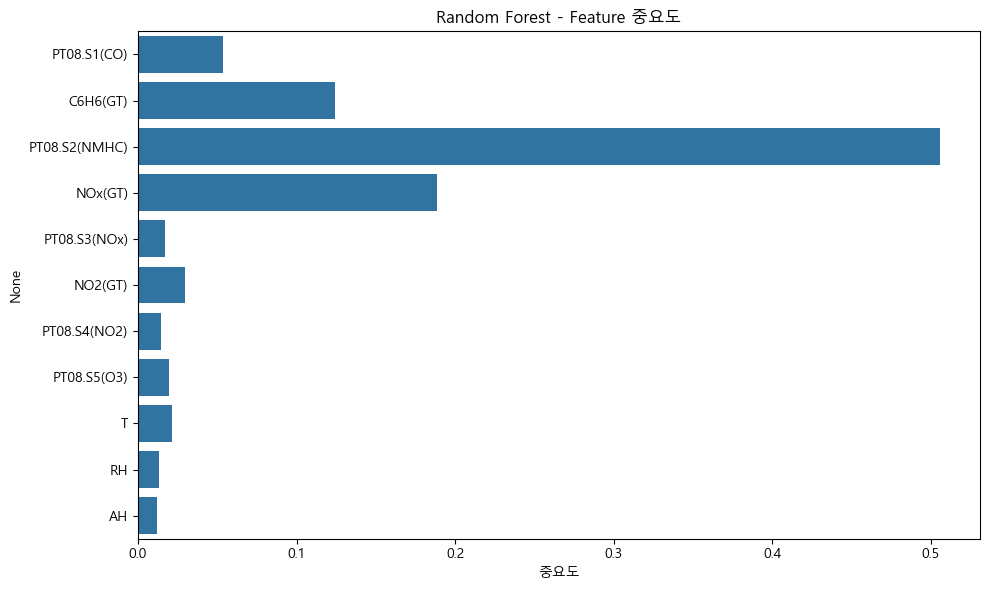

In [30]:
# Feature 중요도
importances = rf.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names, orient='h')
plt.title('Random Forest - Feature 중요도')
plt.xlabel('중요도')
plt.tight_layout()
plt.show()

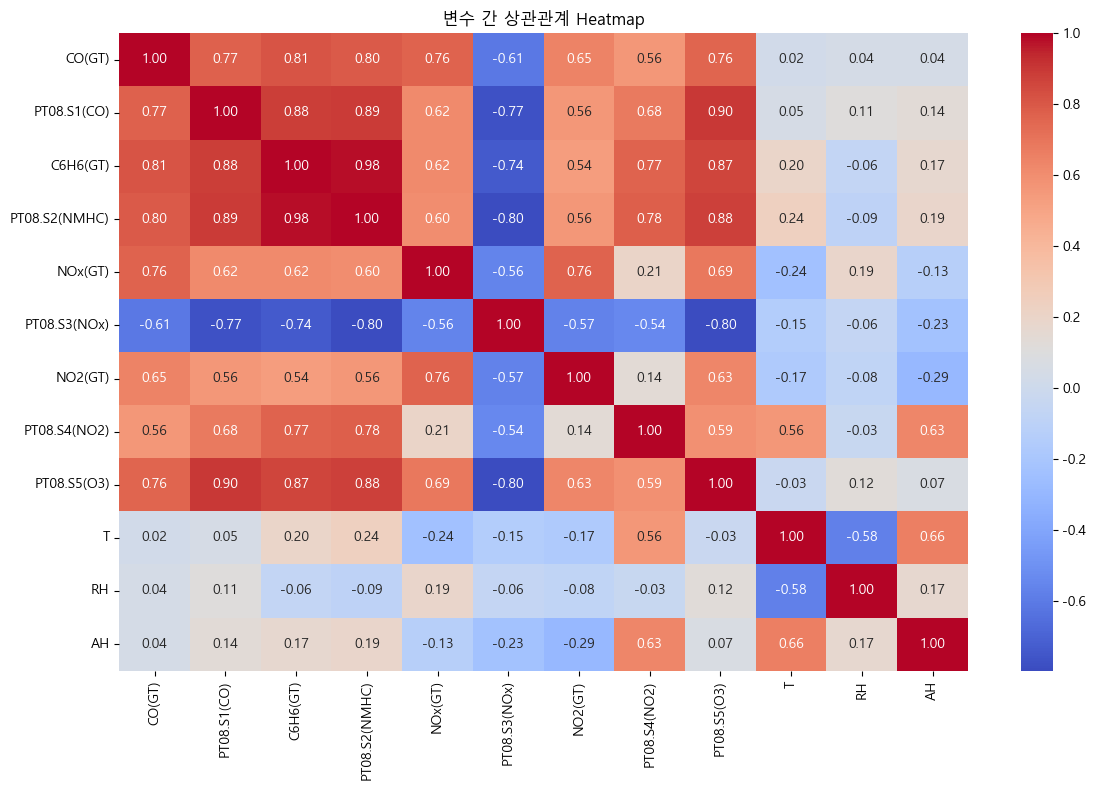

In [31]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('변수 간 상관관계 Heatmap')
plt.tight_layout()
plt.show()

In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
vif_data = vif_data.sort_values('VIF', ascending=False)
print(vif_data)

          Feature         VIF
2   PT08.S2(NMHC)  399.706956
6    PT08.S4(NO2)  224.146729
0     PT08.S1(CO)  199.800564
10             AH   80.536632
8               T   77.604923
9              RH   72.412065
7     PT08.S5(O3)   66.608992
1        C6H6(GT)   63.071984
5         NO2(GT)   27.489897
4    PT08.S3(NOx)   23.667851
3         NOx(GT)   11.436367


In [33]:
from sklearn.decomposition import PCA

# PCA 적용
pca = PCA(n_components=0.95)  # 95% 정보 유지
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"원래 변수 개수: {X_train_scaled.shape[1]}")
print(f"PCA 후 변수 개수: {X_train_pca.shape[1]}")
print(f"설명된 분산 비율: {pca.explained_variance_ratio_}")


원래 변수 개수: 11
PCA 후 변수 개수: 5
설명된 분산 비율: [0.53299653 0.21989212 0.1216325  0.04940931 0.03125949]


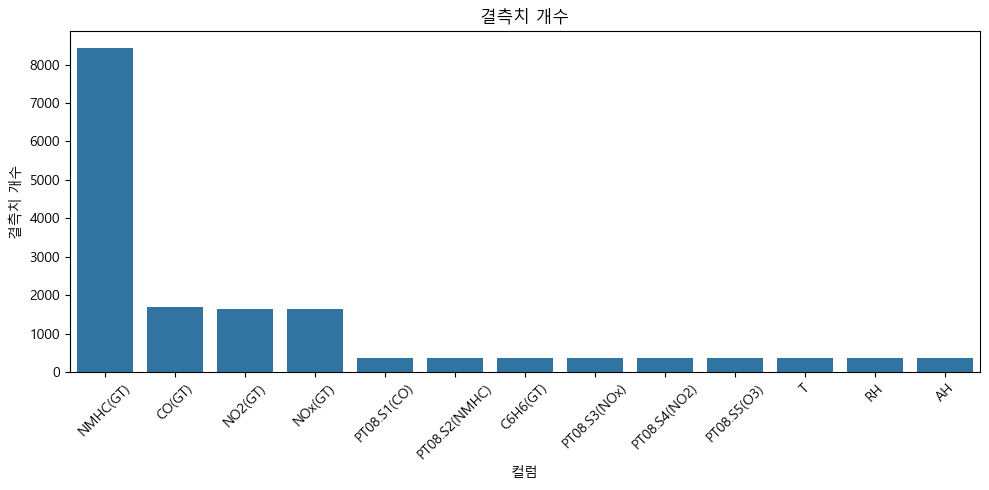

In [34]:
# 결측치 통계 시각화 (전처리 전 기준)
from ucimlrepo import fetch_ucirepo

air_quality = fetch_ucirepo(id=360)
df_raw = pd.concat([air_quality.data.features, air_quality.data.targets], axis=1)
df_raw.replace(-200, pd.NA, inplace=True)

missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=missing.index, y=missing.values)
plt.title('결측치 개수')
plt.xlabel('컬럼')
plt.ylabel('결측치 개수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
# PCA 적용 후 RandomForest 학습
rf_pca = RandomForestRegressor(n_estimators=200, random_state=42)
rf_pca.fit(X_train_pca, y_train)
y_pred_pca = rf_pca.predict(X_test_pca)

print(f"PCA 적용 전 RF R2: 0.8743")
print(f"PCA 적용 후 RF R2: {r2_score(y_test, y_pred_pca):.4f}")
print(f"PCA 적용 전 RF RMSE: 0.4831")
print(f"PCA 적용 후 RF RMSE: {mean_squared_error(y_test, y_pred_pca)**.5:.4f}")

PCA 적용 전 RF R2: 0.8743
PCA 적용 후 RF R2: 0.8481
PCA 적용 전 RF RMSE: 0.4831
PCA 적용 후 RF RMSE: 0.5311


In [36]:
import pickle

# 학습된 RF 모델 저장
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

# 스케일러 저장
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("모델 저장 완료!")

모델 저장 완료!


In [37]:
import sys
print(sys.executable)
print(sys.version)

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import xgboost
import seaborn
import statsmodels
print("모든 라이브러리 정상 import!")


c:\Users\amino\AppData\Local\Programs\Python\Python311\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
모든 라이브러리 정상 import!


In [38]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [39]:
import pickle

# 학습된 RF 모델 저장
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

# 스케일러 저장
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("모델 저장 완료!")

모델 저장 완료!


In [ ]:
import streamlit as st
import pickle
import numpy as np

with open('rf_model.pkl', 'rb') as f:
    model = pickle.load(f)

st.title("🌬️ 대기질 CO 농도 예측 시스템")
st.write("센서값을 입력하면 일산화탄소(CO) 농도를 예측합니다.")

st.sidebar.header("센서값 입력")

pt08_s1 = st.sidebar.slider("PT08.S1(CO) 센서값", 0, 2000, 1000)
c6h6 = st.sidebar.slider("C6H6(GT) 벤젠 농도", 0.0, 20.0, 5.0)
pt08_s2 = st.sidebar.slider("PT08.S2(NMHC) 센서값", 0, 2000, 1000)
nox = st.sidebar.slider("NOx(GT) 질소산화물", 0, 500, 100)
pt08_s3 = st.sidebar.slider("PT08.S3(NOx) 센서값", 0, 2000, 1000)
no2 = st.sidebar.slider("NO2(GT) 이산화질소", 0, 300, 100)
pt08_s4 = st.sidebar.slider("PT08.S4(NO2) 센서값", 0, 2000, 1000)
pt08_s5 = st.sidebar.slider("PT08.S5(O3) 오존센서", 0, 2000, 1000)
temp = st.sidebar.slider("T 온도 (℃)", -10.0, 45.0, 20.0)
rh = st.sidebar.slider("RH 상대습도 (%)", 0.0, 100.0, 50.0)
ah = st.sidebar.slider("AH 절대습도", 0.0, 2.0, 1.0)

input_data = np.array([[pt08_s1, c6h6, pt08_s2, nox, pt08_s3, no2, pt08_s4, pt08_s5, temp, rh, ah]])
prediction = model.predict(input_data)

st.subheader("예측 결과")
st.metric(label="CO 농도 예측값 (mg/m³)", value=f"{prediction[0]:.2f}")

if prediction[0] < 2:
    st.success("✅ 안전 수준입니다.")
elif prediction[0] < 5:
    st.warning("⚠️ 주의 수준입니다.")
else:
    st.error("🚨 위험 수준입니다!")

ModuleNotFoundError: No module named 'streamlit'